In [ ]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from pathlib import Path

sns.set_style("whitegrid")

RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)



Matplotlib is building the font cache; this may take a moment.


In [3]:
DATA_PATH = Path("../data/fraud_detection_paysim_dataset.csv")

df = pd.read_csv(DATA_PATH)

print("Dataset Shape:", df.shape)
df.head()

Dataset Shape: (6362620, 11)


,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
0,1,PAYMENT,9839.64,C1231006815,170136.0,160296.36,M1979787155,0.0,0.0,0,0
1,1,PAYMENT,1864.28,C1666544295,21249.0,19384.72,M2044282225,0.0,0.0,0,0
2,1,TRANSFER,181.00,C1305486145,181.0,0.00,C553264065,0.0,0.0,1,0
3,1,CASH_OUT,181.00,C840083671,181.0,0.00,C38997010,21182.0,0.0,1,0
4,1,PAYMENT,11668.14,C2048537720,41554.0,29885.86,M1230701703,0.0,0.0,0,0


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6362620 entries, 0 to 6362619
Data columns (total 11 columns):
 #   Column          Dtype  
---  ------          -----  
 0   step            int64  
 1   type            object 
 2   amount          float64
 3   nameOrig        object 
 4   oldbalanceOrg   float64
 5   newbalanceOrig  float64
 6   nameDest        object 
 7   oldbalanceDest  float64
 8   newbalanceDest  float64
 9   isFraud         int64  
 10  isFlaggedFraud  int64  
dtypes: float64(5), int64(3), object(3)
memory usage: 534.0+ MB


RangeIndex: 6362620 entries, 0 to 6362619
Data columns (total 11 columns):
 #   Column          Dtype  
---  ------          -----  
 0   step            int64  
 1   type            object 
 2   amount          float64
 3   nameOrig        object 
 4   oldbalanceOrg   float64
 5   newbalanceOrig  float64
 6   nameDest        object 
 7   oldbalanceDest  float64
 8   newbalanceDest  float64
 9   isFraud         int64  
 10  isFlaggedFraud  int64  
dtypes: float64(5), int64(3), object(3)
memory usage: 534.0+ MB

In [5]:
df.isnull().sum()

step              0
type              0
amount            0
nameOrig          0
oldbalanceOrg     0
newbalanceOrig    0
nameDest          0
oldbalanceDest    0
newbalanceDest    0
isFraud           0
isFlaggedFraud    0
dtype: int64

step              0
type              0
amount            0
nameOrig          0
oldbalanceOrg     0
newbalanceOrig    0
nameDest          0
oldbalanceDest    0
newbalanceDest    0
isFraud           0
isFlaggedFraud    0
dtype: int64

The dataset contains no missing values, so no imputation is required.

In [6]:
fraud_counts = df["isFraud"].value_counts()

print(fraud_counts)
print("Fraud ratio:", fraud_counts[1] / fraud_counts.sum())

isFraud
0    6354407
1       8213
Name: count, dtype: int64
Fraud ratio: 0.001290820448180152


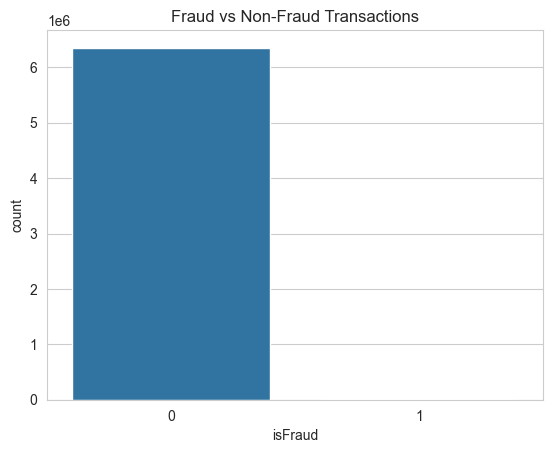

In [7]:
sns.countplot(x="isFraud", data=df)
plt.title("Fraud vs Non-Fraud Transactions")
plt.show()

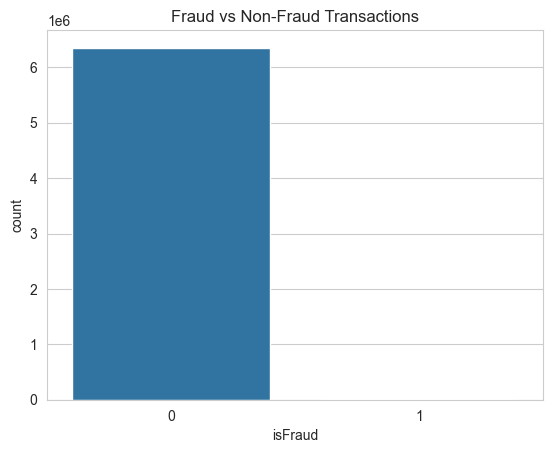 

The dataset is highly imbalanced.
isFraud
0    6354407
1       8213
Name: count, dtype: int64
Fraud ratio: 0.001290820448180152
Only about 0.13% of transactions are fraudulent.
Accuracy is therefore unreliable metric, we can use F1-score and AUROC.

Plotting the count does not provide a good extimation. Therefore plotting logs of count

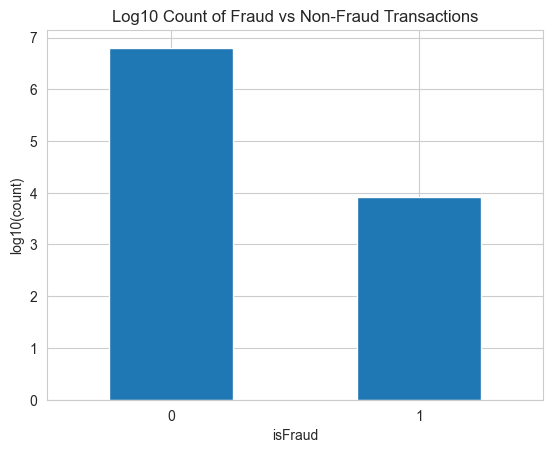

In [8]:
fraud_counts = df["isFraud"].value_counts()

log_counts = np.log10(fraud_counts)

log_counts.plot(kind="bar")

plt.title("Log10 Count of Fraud vs Non-Fraud Transactions")
plt.ylabel("log10(count)")
plt.xticks(rotation=0)

plt.show()

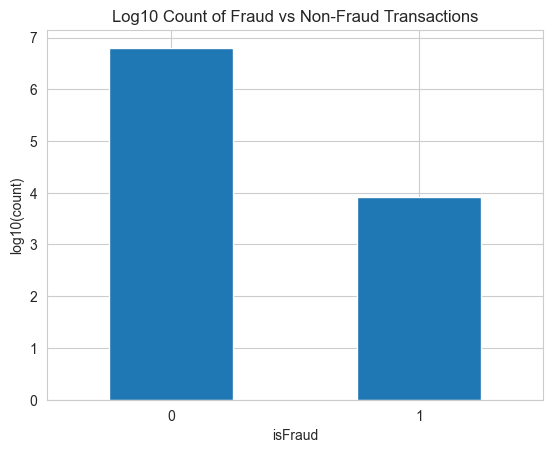

Due to extreme imbalance in the count plot the fraudlent count is almost invisible. Using logaritmic scale we can see that the fraudlent transactions are almost 10^3.9 and non fradulent transactions are almost 10^6.8 . 
Checking the imbalance for different transaction types and amounts next.

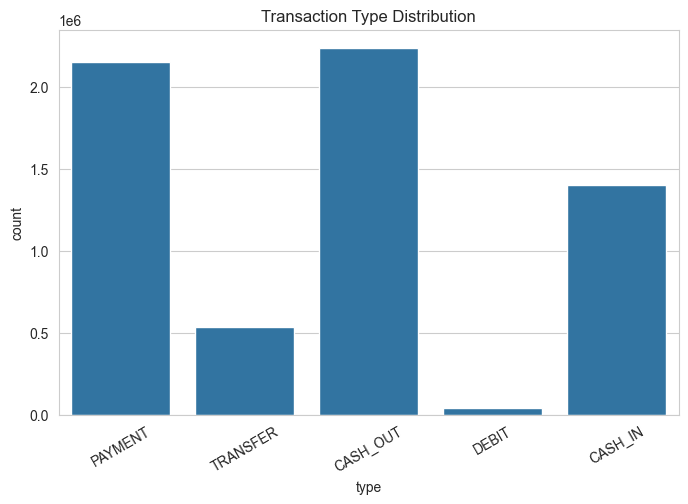

In [9]:
plt.figure(figsize=(8,5))
sns.countplot(x="type", data=df)
plt.title("Transaction Type Distribution")
plt.xticks(rotation=30)
plt.show()

Sample set contains five types of transactions Payment, transfer, cash_out, debit and cash_in.
Majority of transactions are payment and cash_out . Followed by cash_in which are about 70% of Payments. Then Transfers which are about 25% of Payments and then debit transactions which are very less compared to others

In [10]:
pd.crosstab(df["type"], df["isFraud"])

isFraud,0,1
type,,
CASH_IN,1399284,0
CASH_OUT,2233384,4116
DEBIT,41432,0
PAYMENT,2151495,0
TRANSFER,528812,4097



isFraud	0	1
type		
CASH_IN	1399284	0
CASH_OUT	2233384	4116
DEBIT	41432	0
PAYMENT	2151495	0
TRANSFER	528812	4097

Only transfers and cash_outs in the sample set are actually fraudulent. Key takeaways:
We can train model using all transactions and then by using only cash_out and transfer.
Transaction type is an important predictive feature.
Hind sight fraud attempts primarily involve transactions where funds are transferred or withdrawn.
Also the count for fraudulent transactions in Transfer and cash_out is almost the same, even though there are almost 4 time more cash_out transactions than transfer transactions. Comparing frad probablity per type.

In [11]:
fraud_rate_by_type = df.groupby("type")["isFraud"].mean()

fraud_rate_by_type.sort_values(ascending=False)

type
TRANSFER    0.007688
CASH_OUT    0.001840
CASH_IN     0.000000
DEBIT       0.000000
PAYMENT     0.000000
Name: isFraud, dtype: float64

type
TRANSFER    0.007688
CASH_OUT    0.001840
CASH_IN     0.000000
DEBIT       0.000000
PAYMENT     0.000000
Name: isFraud, dtype: float64
About 0.76% of transfers and 0.18% of cash_out are fraudulent.

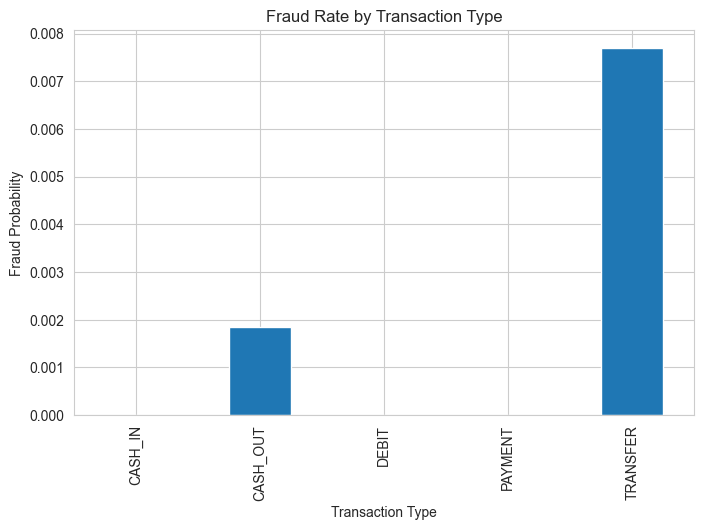

In [12]:
plt.figure(figsize=(8,5))

fraud_rate_by_type.plot(kind="bar")

plt.title("Fraud Rate by Transaction Type")
plt.ylabel("Fraud Probability")
plt.xlabel("Transaction Type")

plt.show()

Transaction amount distribution for fraud and non-fraud transactions

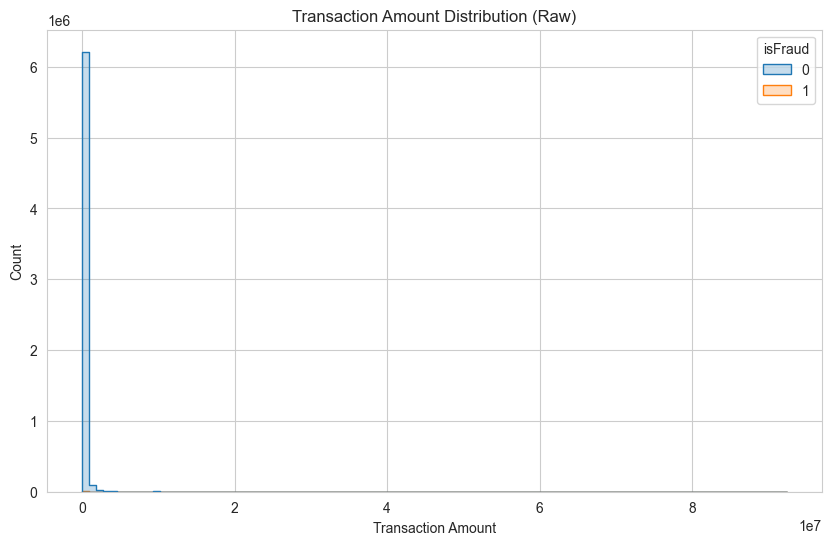

In [18]:
plt.figure(figsize=(10,6))

sns.histplot(
    data=df,
    x="amount",
    hue="isFraud",
    bins=100,
    element="step",
    stat="count"
)

plt.title("Transaction Amount Distribution (Raw)")
plt.xlabel("Transaction Amount")
plt.ylabel("Count")

plt.show()

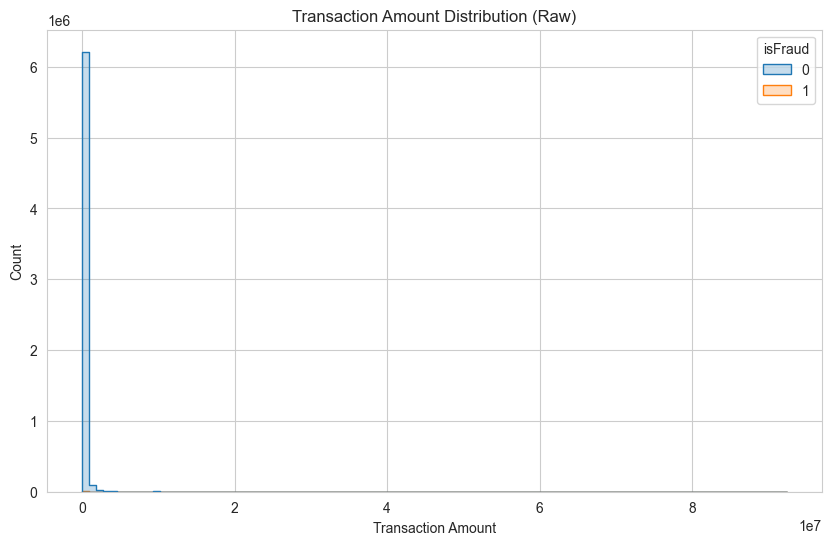
Hard to visualize using this counts, as the low count transactions are huge. using log sacle

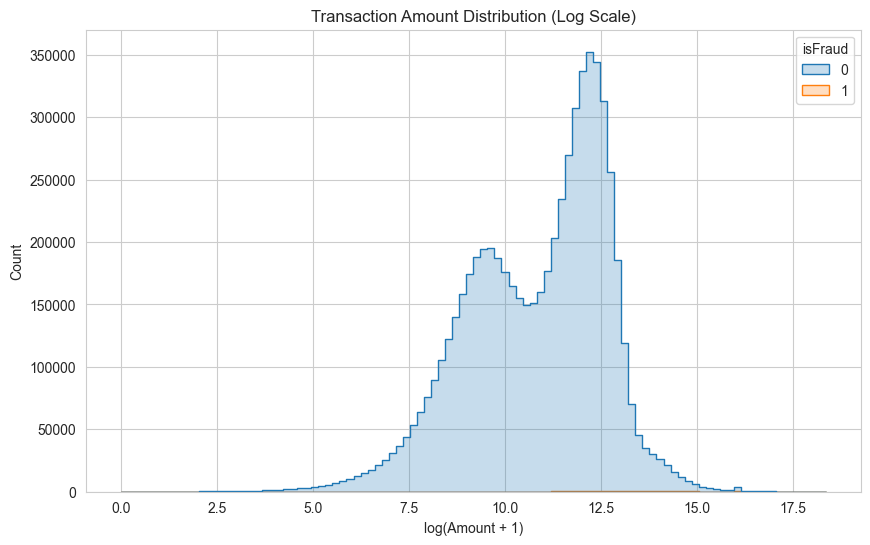

In [19]:
plt.figure(figsize=(10,6))

sns.histplot(
    data=df,
    x=np.log1p(df["amount"]),
    hue="isFraud",
    bins=100,
    element="step",
    stat="count"
)

plt.title("Transaction Amount Distribution (Log Scale)")
plt.xlabel("log(Amount + 1)")
plt.ylabel("Count")

plt.show()

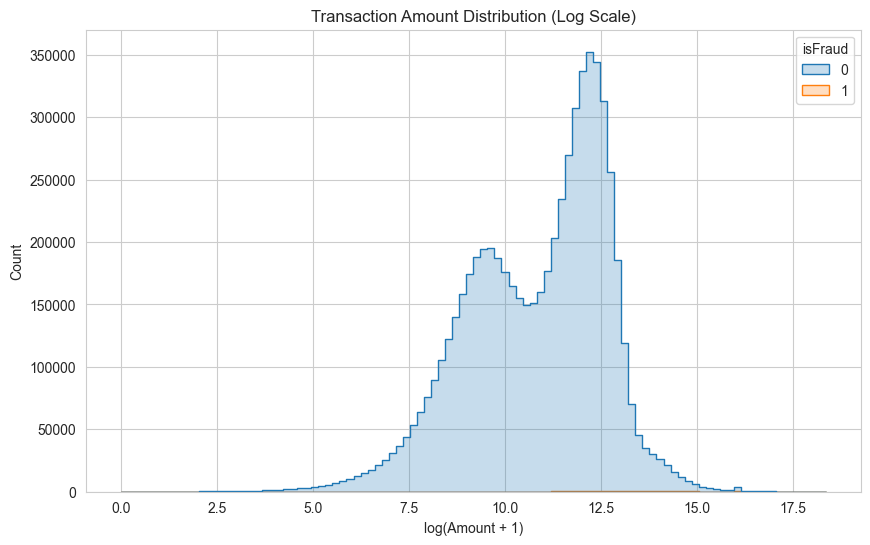

Provides a good distribution for Amount, but due to scale the difference between frad and non-fraud is not visible.
Plotting the non-fraud distribution separately

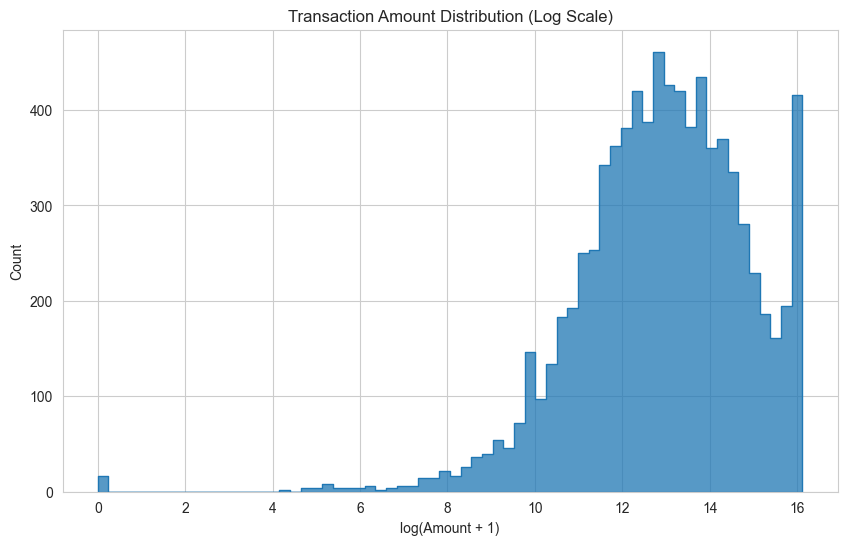

In [20]:
plt.figure(figsize=(10,6))

sns.histplot(
    data=df,
    x=np.log1p(df[df["isFraud"] == 1]["amount"]),
    element="step",
    stat="count"
)

plt.title("Transaction Amount Distribution (Log Scale)")
plt.xlabel("log(Amount + 1)")
plt.ylabel("Count")

plt.show()

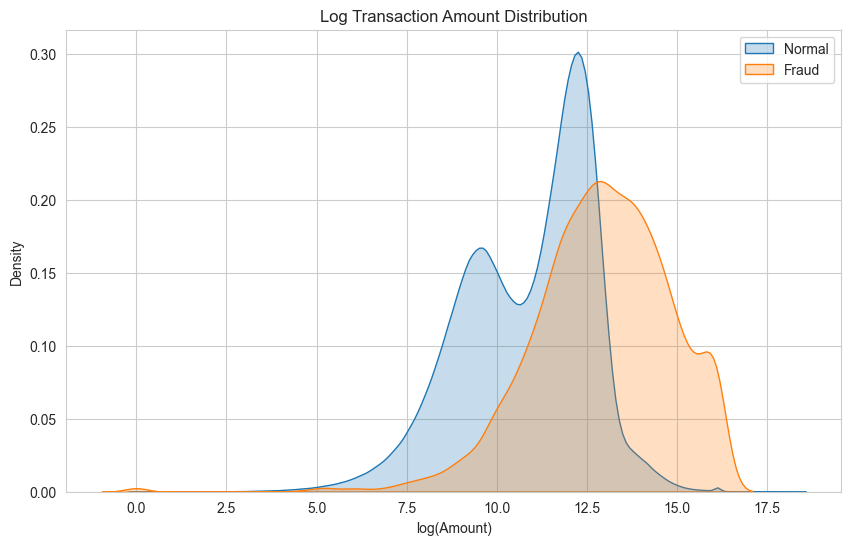

In [13]:
plt.figure(figsize=(10,6))

sns.kdeplot(
    np.log1p(df[df["isFraud"] == 0]["amount"]),
    label="Normal",
    fill=True
)

sns.kdeplot(
    np.log1p(df[df["isFraud"] == 1]["amount"]),
    label="Fraud",
    fill=True
)

plt.title("Log Transaction Amount Distribution")
plt.xlabel("log(Amount)")
plt.ylabel("Density")

plt.legend()

plt.show()

Compared to the normal transactions, the frauduluent transactions are skewed slightly more to the right. Therefore comparing density, there are more fraudulent transactions for higher amounts.